 9. In this exercise, we will predict the number of applications received
 using the other variables in the College data set.
 (a) Split the data set into a training set and a test set.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV 
from sklearn.preprocessing import PolynomialFeatures, scale, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from itertools import combinations
from tqdm import tqdm

In [2]:
college = pd.read_csv(r"D:\ML&Fintech\data_ML&Fintech\College.csv", index_col=0).dropna()
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
college['Private'] = pd.get_dummies(college['Private']).iloc[:, 0]

In [4]:
college.isna().any()

Private        False
Apps           False
Accept         False
Enroll         False
Top10perc      False
Top25perc      False
F.Undergrad    False
P.Undergrad    False
Outstate       False
Room.Board     False
Books          False
Personal       False
PhD            False
Terminal       False
S.F.Ratio      False
perc.alumni    False
Expend         False
Grad.Rate      False
dtype: bool

In [6]:
X_train, X_test, y_train, y_test = train_test_split(college.drop(['Apps'], axis=1), college.Apps, test_size=0.5, random_state=1)

(b) Fit a linear model using least squares on the training set, and
 report the test error obtained.

In [7]:
lr = LinearRegression(fit_intercept=True)

lr.fit(X_train, y_train)
mean_squared_error(y_test, lr.predict(X_test))

1425055.5873112192

Text(0.5, 1.0, 'Residual Plot')

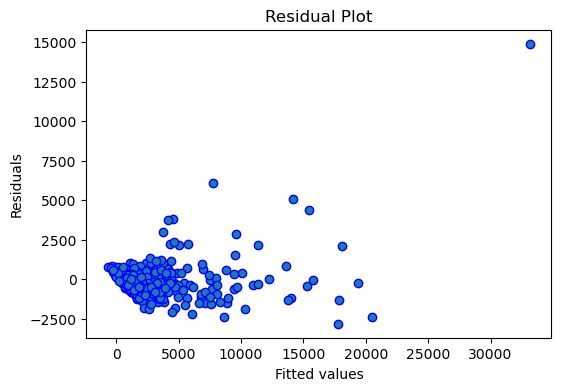

In [8]:
fitted_values = lr.predict(X_test)
residuals = y_test - fitted_values

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(fitted_values, residuals, edgecolors='b');
ax.set_xlabel('Fitted values');
ax.set_ylabel('Residuals');
ax.set_title('Residual Plot')

#### From the plot above, it is evident that the residual plot has a pattern, which may indicate that the relationship between the response and the predictors is nonlinear.

 (c) Fit a ridge regression model on the training set, with λ chosen
 by cross-validation. Report the test error obtained.

In [10]:
alphas = np.logspace(-4, 0, 100)

ridgecv = RidgeCV(alphas=alphas, store_cv_results=True)
ridgecv.fit(X_train, y_train)

print(f'Optimal value of alpha chosen by cross-valiation: {ridgecv.alpha_}')

Optimal value of alpha chosen by cross-valiation: 1.0


In [12]:
# Min mse value obtained by cross-validation
mses = np.mean(ridgecv.cv_results_, axis=0)
min_mse = np.min(mses)
min_mse

np.float64(1291210.5443199957)

In [13]:
pd.Series(ridgecv.coef_.flatten(), index=X_train.columns)

Private        435.222306
Accept           1.142032
Enroll           0.487520
Top10perc       62.793075
Top25perc      -22.722444
F.Undergrad     -0.005927
P.Undergrad      0.016667
Outstate        -0.067384
Room.Board       0.247228
Books           -0.207027
Personal        -0.085628
PhD             -6.257675
Terminal        -3.601403
S.F.Ratio        7.825445
perc.alumni    -10.548037
Expend           0.057815
Grad.Rate       12.040150
dtype: float64

 (d) Fit a lasso model on the training set, with λ chosen by cross
validation. Report the test error obtained, along with the num
ber of non-zero coefficient estimates.

In [14]:
lassocv = LassoCV(alphas=alphas, cv=10, max_iter=1000)
lassocv.fit(X_train, y_train)

print(f'Optimal value of alpha chosen by cross-valiation: {lassocv.alpha_}')

Optimal value of alpha chosen by cross-valiation: 1.0


In [15]:
mses = np.mean(lassocv.mse_path_, axis=1)
min_mse = np.min(mses)
min_mse

np.float64(1284070.9604433668)

In [16]:
pd.Series(lassocv.coef_.flatten(), index=X_train.columns)

Private        437.153494
Accept           1.142031
Enroll           0.487827
Top10perc       62.755204
Top25perc      -22.697526
F.Undergrad     -0.006027
P.Undergrad      0.016660
Outstate        -0.067307
Room.Board       0.247246
Books           -0.206702
Personal        -0.085643
PhD             -6.257268
Terminal        -3.609594
S.F.Ratio        7.686707
perc.alumni    -10.528380
Expend           0.057793
Grad.Rate       12.031905
dtype: float64

 (e) Fit a PCR model on the training set, with M chosen by cross
validation. Report the test error obtained, along with the value
 of M selected by cross-validation.

In [17]:
scores = []

# Compute the CV Score for no principal components, Linear Reg. only with intercept
scores.append(-np.mean(cross_val_score(LinearRegression(), np.ones((X_train.shape[0], 1)),
                                     y_train, cv=5, scoring='neg_mean_squared_error')))

for i in np.arange(1, X_train.shape[1]+1):
    scaler = StandardScaler()
    X_ = scaler.fit_transform(X_train)
    
    pca = PCA(n_components=i)
    X_pcr = pca.fit_transform(X_)
    
    score = -np.mean(cross_val_score(LinearRegression(), X_pcr[:, :i],
                                    y_train, cv=5, scoring='neg_mean_squared_error'))
    
    scores.append(score)

In [18]:
print(np.argmin(scores), np.min(scores))

16 1312200.0054480801


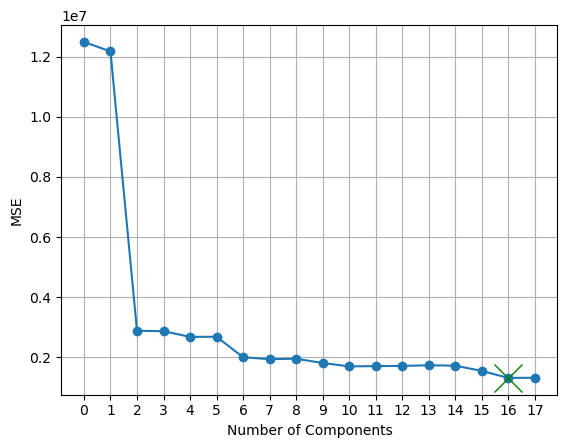

In [19]:
plt.plot(scores, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('MSE')
plt.xticks(np.arange(0, X_train.shape[1]+1, 1))

plt.plot(np.argmin(scores), np.min(scores), 'gx', markersize=20)
plt.grid()

`M=16` is the optimal number of components chosen by cross-validation